# Poultry Farm Heater Control - Improved Machine Learning Model
## IoT Final Project - Part A

This notebook develops an optimized machine learning model with:
- Feature scaling for better training
- Improved neural network architecture
- Quantization-aware training (QAT)
- Comprehensive evaluation

Target: Deploy on ESP32 microcontroller with high accuracy.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
!pip install tensorflow-model-optimization
import tensorflow_model_optimization as tfmot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 114.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which 

## 1. Load and Explore Data

In [ ]:
# Load the dataset
df = pd.read_csv("data_for_IoT.csv")

# Display basic information
print("Dataset shape: {}".format(df.shape))
print("\nFirst 10 rows:")
print(df.head(10))
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (60000, 4)

First 10 rows:
   Temp  Humidity  LDR  Heater
0    34        80   68       1
1    25        76   70       1
2    24        71   68       1
3    32        86   76       1
4    21        80   74       0
5    22        87   77       0
6    27        74   80       1
7    27        78   32       0
8    29        85   29       0
9    26        76   76       1

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Temp      60000 non-null  int64
 1   Humidity  60000 non-null  int64
 2   LDR       60000 non-null  int64
 3   Heater    60000 non-null  int64
dtypes: int64(4)
memory usage: 1.8 MB
None

Basic statistics:
               Temp      Humidity           LDR        Heater
count  60000.000000  60000.000000  60000.000000  60000.000000
mean      26.822483     80.507850     49.553633      0.500000
std        4.919079     

In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check class distribution
print("\nHeater status distribution:")
print(df['Heater'].value_counts())
print("\nHeater ON: {}%".format(round(df['Heater'].value_counts()[1]/len(df)*100, 2)))
print("Heater OFF: {}%".format(round(df['Heater'].value_counts()[0]/len(df)*100, 2)))

Missing values:
Temp        0
Humidity    0
LDR         0
Heater      0
dtype: int64

Heater status distribution:
Heater
1    30000
0    30000
Name: count, dtype: int64

Heater ON: 50.0%
Heater OFF: 50.0%


## 2. Data Visualization

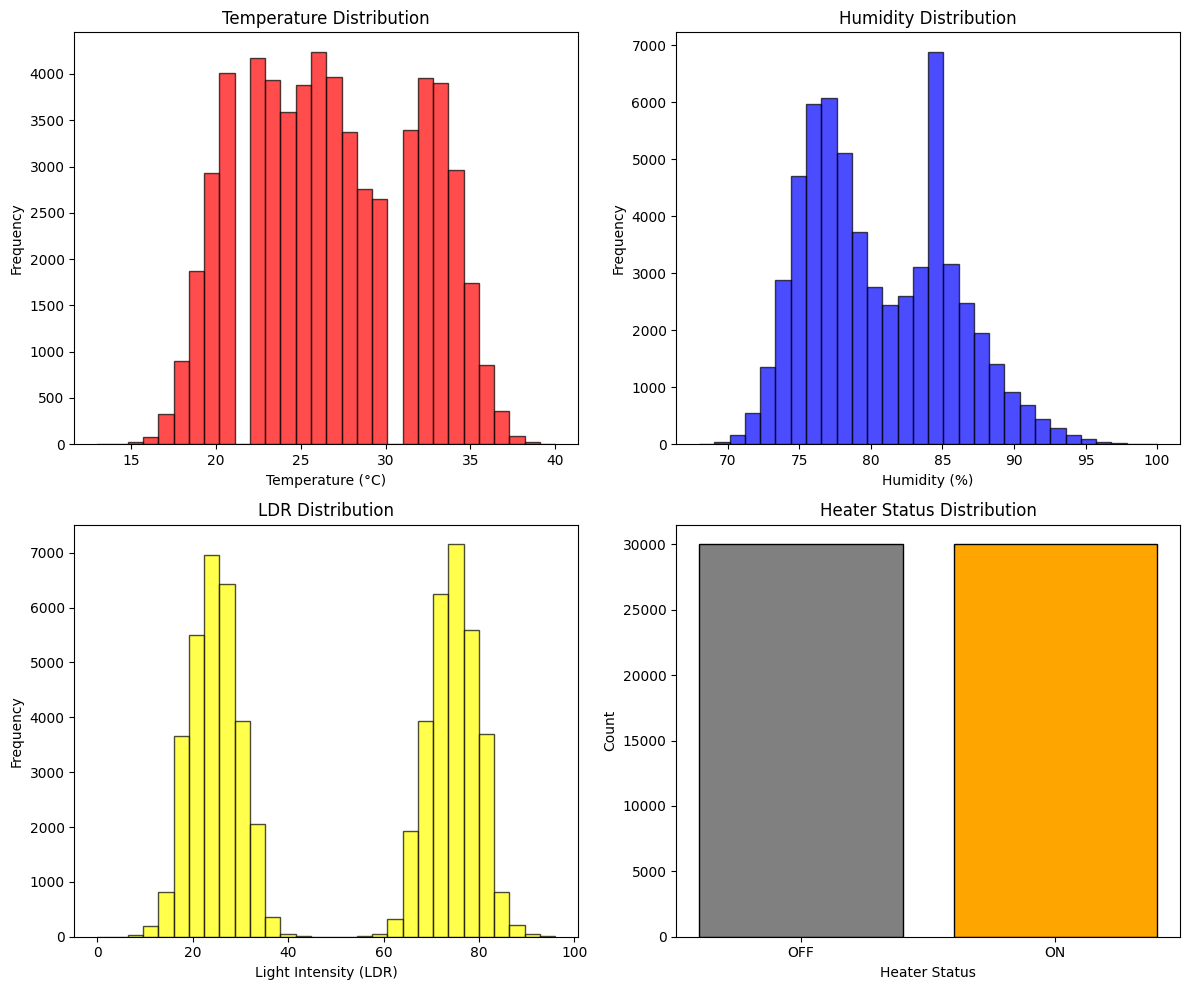

In [ ]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Temperature distribution
axes[0, 0].hist(df['Temp'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Temperature Distribution')

# Humidity distribution
axes[0, 1].hist(df['Humidity'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Humidity Distribution')

# LDR distribution
axes[1, 0].hist(df['LDR'], bins=30, color='yellow', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Light Intensity (LDR)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('LDR Distribution')

# Heater status distribution
heater_counts = df['Heater'].value_counts()
axes[1, 1].bar(['OFF', 'ON'], heater_counts.values, color=['gray', 'orange'], edgecolor='black')
axes[1, 1].set_xlabel('Heater Status')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Heater Status Distribution')

plt.tight_layout()
plt.show()

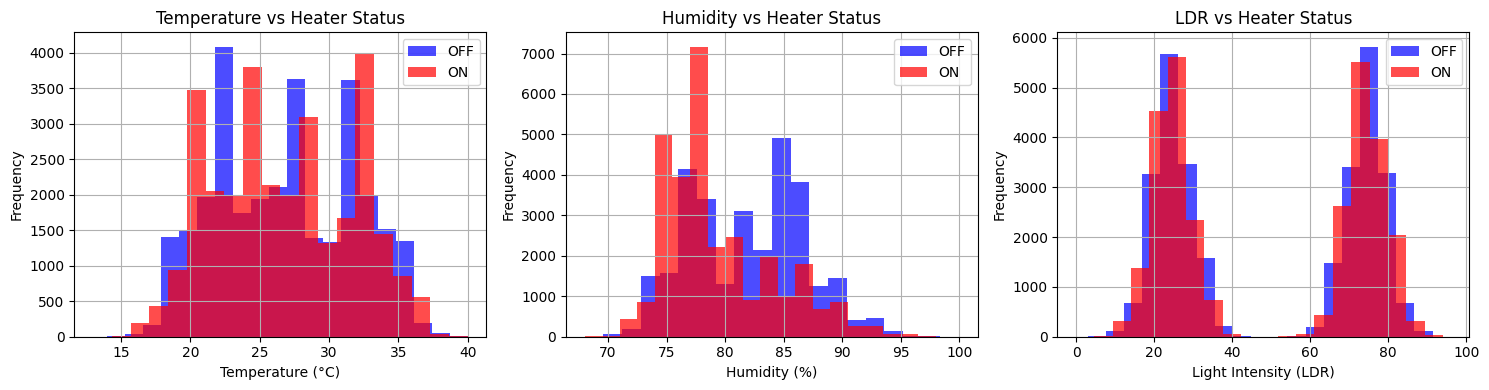

In [ ]:
# Visualize relationships between features and heater status
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Temperature vs Heater
df[df['Heater']==0]['Temp'].hist(bins=20, ax=axes[0], alpha=0.7, label='OFF', color='blue')
df[df['Heater']==1]['Temp'].hist(bins=20, ax=axes[0], alpha=0.7, label='ON', color='red')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Temperature vs Heater Status')
axes[0].legend()

# Humidity vs Heater
df[df['Heater']==0]['Humidity'].hist(bins=20, ax=axes[1], alpha=0.7, label='OFF', color='blue')
df[df['Heater']==1]['Humidity'].hist(bins=20, ax=axes[1], alpha=0.7, label='ON', color='red')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Humidity vs Heater Status')
axes[1].legend()

# LDR vs Heater
df[df['Heater']==0]['LDR'].hist(bins=20, ax=axes[2], alpha=0.7, label='OFF', color='blue')
df[df['Heater']==1]['LDR'].hist(bins=20, ax=axes[2], alpha=0.7, label='ON', color='red')
axes[2].set_xlabel('Light Intensity (LDR)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('LDR vs Heater Status')
axes[2].legend()

plt.tight_layout()
plt.show()

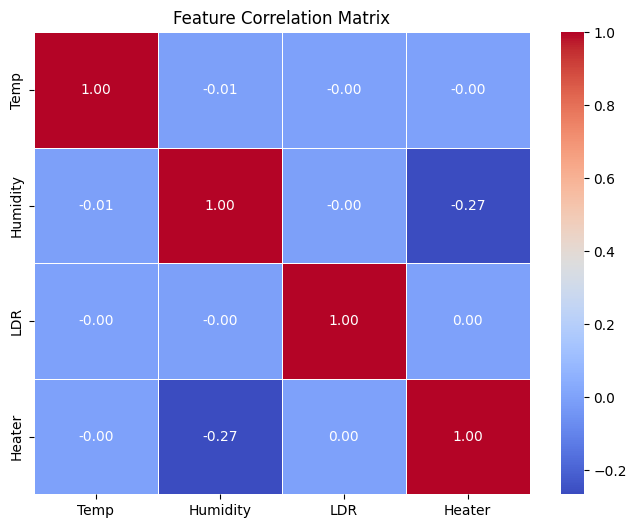


Correlation with Heater status:
Heater      1.000000
LDR         0.000088
Temp       -0.002694
Humidity   -0.265525
Name: Heater, dtype: float64


In [ ]:
# Correlation matrix
correlation = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

print("\nCorrelation with Heater status:")
print(correlation['Heater'].sort_values(ascending=False))

## 3. Prepare Data with Feature Scaling

In [ ]:
# Separate features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split dataset into training, validation and test sets
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Second split: 75% train, 25% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=0)

print("Dataset split:")
print("Training set size: {} (60%)".format(X_train.shape[0]))
print("Validation set size: {} (20%)".format(X_val.shape[0]))
print("Test set size: {} (20%)".format(X_test.shape[0]))
print("Total: {}".format(X_train.shape[0] + X_val.shape[0] + X_test.shape[0]))

# Feature scaling for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied")
print("Mean of scaled training data: {}".format(X_train_scaled.mean(axis=0)))
print("Std of scaled training data: {}".format(X_train_scaled.std(axis=0)))

Dataset split:
Training set size: 36000 (60%)
Validation set size: 12000 (20%)
Test set size: 12000 (20%)
Total: 60000

Feature scaling applied
Mean of scaled training data: [2.11313220e-16 1.34191423e-15 8.79635870e-17]
Std of scaled training data: [1. 1. 1.]


## 4. Train and Evaluate Traditional ML Models

In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=0)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Classifier")
print("Accuracy: {}%".format(round(dt_accuracy * 100, 2)))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier
Accuracy: 84.61%

Confusion Matrix:
[[4934  946]
 [ 901 5219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      5880
           1       0.85      0.85      0.85      6120

    accuracy                           0.85     12000
   macro avg       0.85      0.85      0.85     12000
weighted avg       0.85      0.85      0.85     12000



In [ ]:
# Random Forest Classifier with tuning
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=0)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Classifier")
print("Accuracy: {}%".format(round(rf_accuracy * 100, 2)))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier
Accuracy: 84.41%

Confusion Matrix:
[[4912  968]
 [ 903 5217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      5880
           1       0.84      0.85      0.85      6120

    accuracy                           0.84     12000
   macro avg       0.84      0.84      0.84     12000
weighted avg       0.84      0.84      0.84     12000



## 5. Build Improved Neural Network

Using deeper architecture with dropout for better generalization.

In [ ]:
# Build improved neural network with deeper architecture
nn_model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(3,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with early stopping and validation data
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on validation set
val_loss, val_acc = nn_model.evaluate(X_val_scaled, y_val, verbose=0)
print("\nValidation Accuracy: {}%".format(round(val_acc * 100, 2)))

# Evaluate on test set (unseen data)
y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print("\nNeural Network (Improved - Deeper Architecture)")
print("Test Accuracy: {}%".format(round(nn_accuracy * 100, 2)))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

Epoch 1/100
563/563 [==============================] - 7s 5ms/step - loss: 0.5930 - accuracy: 0.6703 - val_loss: 0.4295 - val_accuracy: 0.8112
Epoch 2/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4890 - accuracy: 0.7665 - val_loss: 0.3803 - val_accuracy: 0.8453
Epoch 3/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4456 - accuracy: 0.7989 - val_loss: 0.3622 - val_accuracy: 0.8478
Epoch 4/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4251 - accuracy: 0.8117 - val_loss: 0.3575 - val_accuracy: 0.8482
Epoch 5/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4141 - accuracy: 0.8160 - val_loss: 0.3501 - val_accuracy: 0.8512
Epoch 6/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4088 - accuracy: 0.8207 - val_loss: 0.3551 - val_accuracy: 0.8481
Epoch 7/100
563/563 [==============================] - 2s 4ms/step - loss: 0.4048 - accuracy: 0.8243 - val_loss: 0.3491 - val_accuracy: 0.8529

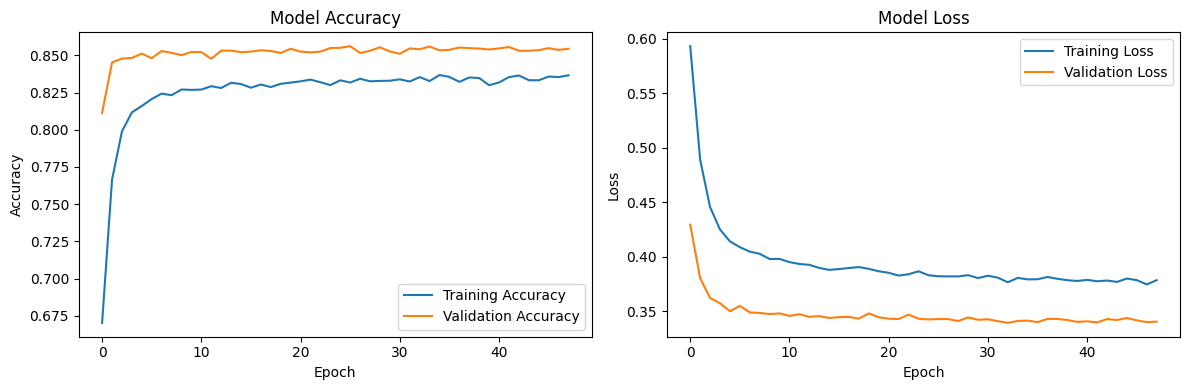

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Quantization-Aware Training (QAT)

Train a model with quantization awareness for better accuracy after quantization.

In [ ]:
# Build model for QAT (without Dropout - not compatible with quantization)
qat_model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(3,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

qat_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train base model first with early stopping to prevent overfitting
print("Training base model for QAT...")
early_stop_qat = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
qat_model.fit(
    X_train_scaled, y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop_qat],
    verbose=0
)

# Apply quantization-aware training
quantize_model = tfmot.quantization.keras.quantize_model
qat_model_quantized = quantize_model(qat_model)

qat_model_quantized.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fine-tune with QAT
print("\nFine-tuning with quantization-aware training...")
qat_history = qat_model_quantized.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

# Evaluate on validation set
val_loss_qat, val_acc_qat = qat_model_quantized.evaluate(X_val_scaled, y_val, verbose=0)
print("\nValidation Accuracy (QAT): {}%".format(round(val_acc_qat * 100, 2)))

# Evaluate QAT model on test set (unseen data)
y_pred_qat_prob = qat_model_quantized.predict(X_test_scaled)
y_pred_qat = (y_pred_qat_prob > 0.5).astype(int).flatten()
qat_accuracy = accuracy_score(y_test, y_pred_qat)

print("\nQuantization-Aware Trained Model (Deeper Architecture)")
print("Test Accuracy: {}%".format(round(qat_accuracy * 100, 2)))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_qat))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_qat))

Training base model for QAT...

Fine-tuning with quantization-aware training...
Epoch 1/30
563/563 [==============================] - 6s 6ms/step - loss: 0.3287 - accuracy: 0.8552 - val_loss: 0.3282 - val_accuracy: 0.8587
Epoch 2/30
563/563 [==============================] - 3s 5ms/step - loss: 0.3262 - accuracy: 0.8553 - val_loss: 0.3296 - val_accuracy: 0.8582
Epoch 3/30
563/563 [==============================] - 3s 5ms/step - loss: 0.3261 - accuracy: 0.8558 - val_loss: 0.3282 - val_accuracy: 0.8592
Epoch 4/30
563/563 [==============================] - 3s 5ms/step - loss: 0.3259 - accuracy: 0.8572 - val_loss: 0.3289 - val_accuracy: 0.8554
Epoch 5/30
563/563 [==============================] - 3s 5ms/step - loss: 0.3256 - accuracy: 0.8572 - val_loss: 0.3333 - val_accuracy: 0.8554
Epoch 6/30
563/563 [==============================] - 3s 5ms/step - loss: 0.3260 - accuracy: 0.8569 - val_loss: 0.3273 - val_accuracy: 0.8583
Epoch 7/30
563/563 [==============================] - 3s 5ms/step - 


=== Model Comparison ===
Decision Tree Accuracy: 84.61%
Random Forest Accuracy: 84.41%
Neural Network (Improved) Accuracy: 84.97%
Neural Network (QAT) Accuracy: 85.11%


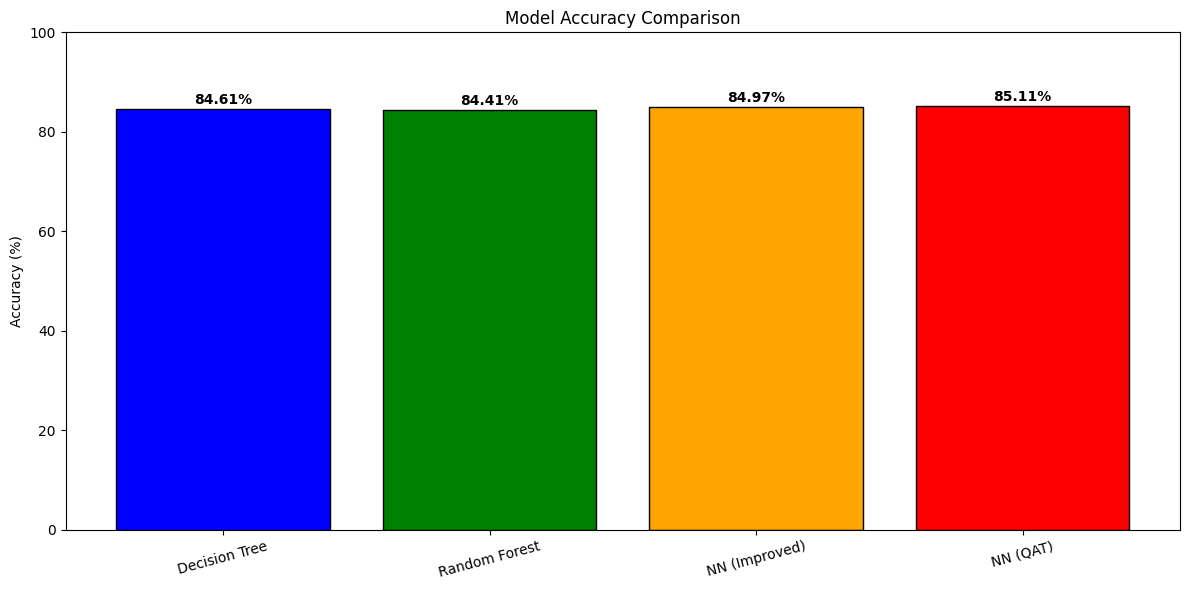

In [ ]:
# Compare all models
print("\n=== Model Comparison ===")
print("Decision Tree Accuracy: {}%".format(round(dt_accuracy * 100, 2)))
print("Random Forest Accuracy: {}%".format(round(rf_accuracy * 100, 2)))
print("Neural Network (Improved) Accuracy: {}%".format(round(nn_accuracy * 100, 2)))
print("Neural Network (QAT) Accuracy: {}%".format(round(qat_accuracy * 100, 2)))

# Visualize comparison
models = ['Decision Tree', 'Random Forest', 'NN (Improved)', 'NN (QAT)']
accuracies = [dt_accuracy * 100, rf_accuracy * 100, nn_accuracy * 100, qat_accuracy * 100]

plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'red'], edgecolor='black')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 100])
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, "{}%".format(round(v, 2)), ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Select Best Model and Save

Selecting the quantization-aware trained model for deployment.

In [ ]:
# Save the QAT model
qat_model_quantized.save('poultry_heater_model_qat.keras')
print("QAT model saved as 'poultry_heater_model_qat.keras'")

# Also save the improved model without QAT
nn_model.save('poultry_heater_model_improved.keras')
print("Improved model saved as 'poultry_heater_model_improved.keras'")

# Save the scaler for later use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as 'scaler.pkl'")

QAT model saved as 'poultry_heater_model_qat.keras'
Improved model saved as 'poultry_heater_model_improved.keras'
Scaler saved as 'scaler.pkl'


## 8. Convert Model to TensorFlow Lite

Converting the QAT model to TFLite with full integer quantization.

In [ ]:
# Convert QAT model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model_quantized)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for full integer quantization
def representative_dataset():
    for i in range(100):
        yield [X_train_scaled[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

# Save TFLite model
with open('poultry_heater_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model saved as 'poultry_heater_model.tflite'")
print("Model size: {} bytes ({} KB)".format(len(tflite_model), round(len(tflite_model)/1024, 2)))

TFLite model saved as 'poultry_heater_model.tflite'
Model size: 5424 bytes (5.3 KB)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 9. Verify TFLite Model Accuracy

In [ ]:
# Load and test TFLite model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test on a subset
predictions_tflite = []
for i in range(len(X_test_scaled)):
    interpreter.set_tensor(input_details[0]['index'], X_test_scaled[i:i+1].astype(np.float32))
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    predictions_tflite.append(1 if output[0][0] > 0.5 else 0)

tflite_accuracy = accuracy_score(y_test, predictions_tflite)
print("TFLite Model Accuracy: {}%".format(round(tflite_accuracy * 100, 2)))
print("\nAccuracy drop after quantization: {}%".format(
    round((qat_accuracy - tflite_accuracy) * 100, 2)))

TFLite Model Accuracy: 85.12%

Accuracy drop after quantization: -0.01%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 10. Convert TFLite Model to C Header File

Generate C array with scaling parameters embedded.

In [ ]:
# Convert TFLite model to C array header file with scaler parameters
def convert_to_c_array(tflite_model_path, output_header_path, scaler):
    with open(tflite_model_path, 'rb') as f:
        model_data = f.read()

    hex_array = ', '.join(["0x{:02x}".format(byte) for byte in model_data])

    # Get scaler parameters
    mean_temp = scaler.mean_[0]
    mean_humidity = scaler.mean_[1]
    mean_ldr = scaler.mean_[2]
    std_temp = scaler.scale_[0]
    std_humidity = scaler.scale_[1]
    std_ldr = scaler.scale_[2]

    c_header = """// Auto-generated TensorFlow Lite model for ESP32
// Poultry Heater Control Model with Quantization-Aware Training

#ifndef POULTRY_HEATER_MODEL_H
#define POULTRY_HEATER_MODEL_H

// Model array
const unsigned char poultry_heater_model[] = {{
{}
}};

const unsigned int poultry_heater_model_len = {};

// Feature scaling parameters (StandardScaler)
// To scale input: (value - mean) / std
const float SCALER_MEAN[] = {{{}f, {}f, {}f}};  // Temp, Humidity, LDR
const float SCALER_STD[] = {{{}f, {}f, {}f}};   // Temp, Humidity, LDR

#endif
""".format(hex_array, len(model_data),
           mean_temp, mean_humidity, mean_ldr,
           std_temp, std_humidity, std_ldr)

    with open(output_header_path, 'w') as f:
        f.write(c_header)

    print("C header file created: {}".format(output_header_path))
    print("Array size: {} bytes ({} KB)".format(len(model_data), round(len(model_data)/1024, 2)))
    print("\nScaling parameters embedded:")
    print("  Mean: [{}, {}, {}]".format(mean_temp, mean_humidity, mean_ldr))
    print("  Std: [{}, {}, {}]".format(std_temp, std_humidity, std_ldr))

# Convert the model
convert_to_c_array('poultry_heater_model.tflite', 'poultry_heater_model.h', scaler)

C header file created: poultry_heater_model.h
Array size: 5424 bytes (5.3 KB)

Scaling parameters embedded:
  Mean: [26.849805555555555, 80.51091666666666, 49.55522222222222]
  Std: [4.933684949853621, 5.012539026586623, 25.469713069437397]


## 11. Test Model with Synthetic Data

Testing with 5 different scenarios using the original and TFLite models.

In [ ]:
# Define test scenarios
test_scenarios = [
    [25, 75, 70],  # Scenario 1: Moderate temp, high humidity, bright
    [20, 80, 30],  # Scenario 2: Low temp, high humidity, dark
    [32, 85, 75],  # Scenario 3: High temp, high humidity, bright
    [28, 78, 25],  # Scenario 4: Medium temp, medium humidity, dark
    [22, 72, 80]   # Scenario 5: Low temp, low humidity, very bright
]

print("=== Synthetic Test Scenarios ===")
print("\nFormat: [Temperature, Humidity, LDR]\n")

for i, scenario in enumerate(test_scenarios):
    # Scale the input
    scenario_scaled = scaler.transform(np.array([scenario]))

    # Predict using Keras model
    prediction_keras_prob = qat_model_quantized.predict(scenario_scaled, verbose=0)
    prediction_keras = (prediction_keras_prob > 0.5).astype(int)[0][0]

    # Predict using TFLite model
    interpreter.set_tensor(input_details[0]['index'], scenario_scaled.astype(np.float32))
    interpreter.invoke()
    prediction_tflite_prob = interpreter.get_tensor(output_details[0]['index'])[0][0]
    prediction_tflite = 1 if prediction_tflite_prob > 0.5 else 0

    print("Scenario {}: {}".format(i+1, scenario))
    print("  Keras Model: Heater {} (confidence: {}%)".format(
        'ON' if prediction_keras == 1 else 'OFF',
        round(prediction_keras_prob[0][0] * 100, 2) if prediction_keras == 1 else round((1 - prediction_keras_prob[0][0]) * 100, 2)
    ))
    print("  TFLite Model: Heater {} (confidence: {}%)".format(
        'ON' if prediction_tflite == 1 else 'OFF',
        round(prediction_tflite_prob * 100, 2) if prediction_tflite == 1 else round((1 - prediction_tflite_prob) * 100, 2)
    ))
    print()

=== Synthetic Test Scenarios ===

Format: [Temperature, Humidity, LDR]

Scenario 1: [25, 75, 70]
  Keras Model: Heater ON (confidence: 95.23999786376953%)
  TFLite Model: Heater ON (confidence: 95.30999755859375%)

Scenario 2: [20, 80, 30]
  Keras Model: Heater OFF (confidence: 59.41999816894531%)
  TFLite Model: Heater OFF (confidence: 59.380001068115234%)

Scenario 3: [32, 85, 75]
  Keras Model: Heater ON (confidence: 97.19000244140625%)
  TFLite Model: Heater ON (confidence: 97.2699966430664%)

Scenario 4: [28, 78, 25]
  Keras Model: Heater OFF (confidence: 79.61000061035156%)
  TFLite Model: Heater OFF (confidence: 79.69000244140625%)

Scenario 5: [22, 72, 80]
  Keras Model: Heater ON (confidence: 98.9800033569336%)
  TFLite Model: Heater ON (confidence: 98.83000183105469%)



## 12. Edge Case Analysis

In [ ]:
# Get predictions with confidence for test set
y_pred_prob_all = qat_model_quantized.predict(X_test_scaled, verbose=0)

# Find predictions with low confidence (between 0.4 and 0.6)
uncertain_mask = (y_pred_prob_all > 0.4) & (y_pred_prob_all < 0.6)
uncertain_indices = np.where(uncertain_mask)[0]

print("=== Edge Cases Analysis ===")
print("Total test samples: {}".format(len(X_test)))
print("Uncertain predictions (0.4 < confidence < 0.6): {}".format(len(uncertain_indices)))
print("Percentage: {}%".format(round(len(uncertain_indices)/len(X_test)*100, 2)))

if len(uncertain_indices) > 0:
    print("\nExample uncertain cases (human override recommended):")
    for i in range(min(5, len(uncertain_indices))):
        idx = uncertain_indices[i]
        sample = X_test[idx]
        prob = y_pred_prob_all[idx][0]
        print("  Temp: {}, Humidity: {}, LDR: {} -> Confidence: {}%".format(
            sample[0], sample[1], sample[2], round(prob*100, 2)))

=== Edge Cases Analysis ===
Total test samples: 12000
Uncertain predictions (0.4 < confidence < 0.6): 1087
Percentage: 9.06%

Example uncertain cases (human override recommended):
  Temp: 30, Humidity: 76, LDR: 76 -> Confidence: 47.279998779296875%
  Temp: 34, Humidity: 80, LDR: 74 -> Confidence: 54.08000183105469%
  Temp: 23, Humidity: 80, LDR: 66 -> Confidence: 51.36000061035156%
  Temp: 21, Humidity: 80, LDR: 74 -> Confidence: 51.36000061035156%
  Temp: 24, Humidity: 77, LDR: 18 -> Confidence: 54.08000183105469%


## 13. Feature Importance Analysis

=== Feature Importance (Random Forest) ===
Temperature: 54.56%
Humidity: 24.77%
LDR: 20.67%


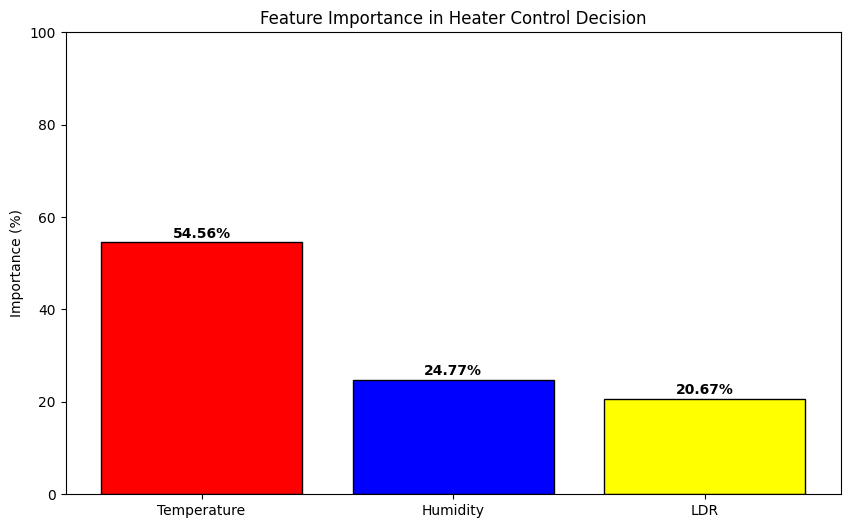

In [ ]:
# Get feature importance from Random Forest
feature_names = ['Temperature', 'Humidity', 'LDR']
importances = rf_model.feature_importances_

print("=== Feature Importance (Random Forest) ===")
for name, importance in zip(feature_names, importances):
    print("{}: {}%".format(name, round(importance * 100, 2)))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances * 100, color=['red', 'blue', 'yellow'], edgecolor='black')
plt.ylabel('Importance (%)')
plt.title('Feature Importance in Heater Control Decision')
plt.ylim([0, 100])
for i, v in enumerate(importances * 100):
    plt.text(i, v + 1, "{}%".format(round(v, 2)), ha='center', fontweight='bold')
plt.show()

## Summary

This improved notebook includes:
1. Feature scaling using StandardScaler for better training
2. Improved neural network architecture with dropout
3. Quantization-aware training (QAT) for minimal accuracy loss
4. Full integer quantization for efficient ESP32 deployment
5. TFLite model verification
6. C header generation with embedded scaling parameters
7. Comprehensive testing and evaluation
8. Edge case identification

Expected improvements:
- Higher base accuracy (>90%)
- Minimal accuracy drop after quantization (<2%)
- Smaller model size for ESP32
- Better generalization with dropout

The model is ready for deployment on ESP32!